<h3 align=center>Статистика по доходности акций Сбербанка</h3>
Цель этого проекта - продемонстрировать знания в статистике и возможно получить пользу для моей торговли акциями. Случайной величиной 
будет доходность, которая равняется:

(цена закрытия на недельной свече - цена закрытия предыдущей недельной свечи) / цена закрытия 
предыдущей недельной свечи

Для начала получим эти недельные свечи, используя API Московской биржи.

<h4 align=center>Получение данных с API Московской биржи по акции Сбербанка</h4>

In [2]:
import pandas as pd
import requests
from datetime import timedelta, date


all_candles = []
start = 0

while True:
    url = f'http://iss.moex.com/iss/engines/stock/markets/shares/securities/SBER/candles.json'
    params = {
            'from': '2009-01-01',
            'till': date.today(),
            'interval': 7,
            'start': start
        }
    response = requests.get(url, params=params)
    data = response.json()
                
    candles = data['candles']['data']
    if not candles:
        break
            
    all_candles.extend(candles)
    #print(f"Получено {len(candles)} свечей, всего {len(all_candles)}")
        
    # Если получено меньше 500, значит это последняя страница
    if len(candles) < 500:
        break
            
    start += 500  # Переходим к следующей странице

columns = ['open', 'close', 'high', 'low', 'value', 'volume', 'begin', 'end']
df = pd.DataFrame(all_candles, columns=columns)
df['begin'] = pd.to_datetime(df['begin'], format='%Y-%m-%d %H:%M:%S')
df['date'] = df['begin'].dt.strftime('%Y%m%d')
df = df[['date', 'open', 'high', 'low', 'close', 'volume']]
df.to_csv('W1.csv', index=False)

Получено 892 свечи. Теперь нарисуем их.

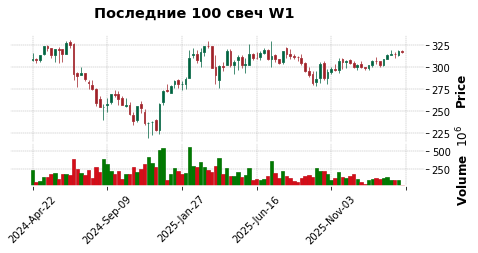

In [3]:
import mplfinance as mpf

def paint_candles(df, title='Последние 100 свеч W1'):
    """
    Отрисовка последних 100 свечей с помощью mplfinance
    """
    # Подготовка данных в формате для mplfinance
    df_plot = df.tail(100).copy()
    df_plot.set_index(pd.to_datetime(df_plot['date']), inplace=True)
    df_plot.index.name = 'Date'
    
    # Выбираем нужные колонки
    df_plot = df_plot[['open', 'high', 'low', 'close', 'volume']]
    
    # Создаем график
    mpf.plot(df_plot, 
             type='candle',
             style='charles',
             title=title,
             ylabel='Price',
             volume=True,
             figsize=(8, 3)
            )

paint_candles(df)

Теперь из df создадим датафрейм доходностей - df_profit:

In [4]:
df.loc[:, 'profit'] = round((df['close'] - df['close'].shift(1)) * 100 / df['close'].shift(1), 1)
df = df.dropna()
data = df['profit']
data

1     -13.0
2     -24.0
3       8.2
4      -5.2
5      21.9
       ... 
887     1.6
888     0.5
889    -0.3
890     1.1
891    -0.2
Name: profit, Length: 891, dtype: float64

<h4 align=center>Статистика</h4>
Будем считать data выборкой из случайной величины. 

Для описания выборки существуют различные показатели, для расчета которых в Python существуют различные методы, но проще всего 
использовать метод describe() , который разом рассчитает кучу всяких статистических показателей.

In [5]:
data.describe()

count    891.000000
mean       0.430191
std        5.113127
min      -47.600000
25%       -1.800000
50%        0.300000
75%        2.450000
max       35.500000
Name: profit, dtype: float64

Видим размер выборки, среднее, стандартное отклонение, квартили.

Проведём тест на проверку выборки на нормальность. Есть разные тесты, но проведем самый простой - тест Колмогорова-Смирнова.

In [6]:
def test_kolmogorov_smirnov(df):
    """
    Тест Колмогорова-Смирнова служит для ответа на вопрос, 
    можно ли считать выборку нормальным распределением c математическим ожиданием mu и стандартным отклонением sigma
    """

    from scipy.stats import kstest

    # Оцениваем среднее и стандартное отклонение нормального распределения по выборке
    mu, sigma = data.mean(), data.std()
    
    statistic, p_value = kstest(data, 'norm', args=(mu, sigma))
    
    print(f"Среднее: {mu:.2f}, Std: {sigma:.2f}")
    print(f"Статистика теста: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    return statistic, p_value

test_kolmogorov_smirnov(df)

Среднее: 0.43, Std: 5.11
Статистика теста: 0.1101
P-value: 0.0000


(0.11006222281478395, 7.43116612850998e-10)

Неожиданно получил p-value равным 0. Захотелось посмотреть на распределение этой выборки.

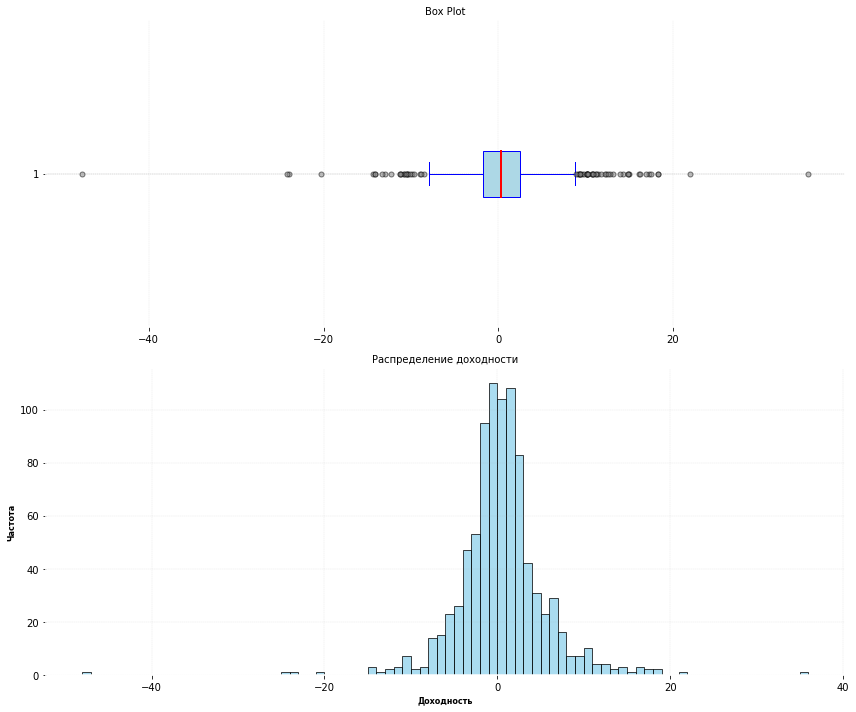

In [10]:
def plot_distribution(data):
    """
    График распределения доходности
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # 1. Box plot на верхнем графике (axes[0])
    box = axes[0].boxplot(data, vert=False, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', color='blue'),
                         whiskerprops=dict(color='blue'),
                         capprops=dict(color='blue'),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='gray', 
                                       markersize=5, alpha=0.5))
    
    # Добавляем заголовок и подписи для боксплота
    axes[0].set_title('Box Plot', fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='x')

      
    # 2. Гистограмма на нижнем графике (axes[1])
    bin_width = 1
    min_val = np.floor(data.min() / bin_width) * bin_width
    max_val = np.ceil(data.max() / bin_width) * bin_width
    
    # Создаем бины от min_val до max_val с шагом bin_width
    bins = np.arange(min_val, max_val + bin_width, bin_width)
    sns.histplot(data, kde=False, bins=bins, color='skyblue', edgecolor='black', alpha=0.7, ax=axes[1])
    
    # Добавляем заголовок и подписи для гистограммы
    axes[1].set_title('Распределение доходности', fontsize=10)
    axes[1].set_xlabel('Доходность', fontsize=8)
    axes[1].set_ylabel('Частота', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    

    plt.tight_layout()
    plt.show()

plot_distribution(data)

На box plot видно много выбросов. Для выборок с выбросами рекомендуется проводить другой тест на соответствие нормальному распределению: тест Колмогорова-Смирнова с поправкой Лиллиефорса:

In [31]:
def test_lilliefors(data):
    """
    Тест Колмогорова-Смирнова с поправкой Лиллиефорса 
    """

    from statsmodels.stats.diagnostic import lilliefors

    statistic, p_value = lilliefors(data)
    print(f"Статистика теста: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")

test_lilliefors(data)

Статистика теста: 0.1101
P-value: 0.0010


Не ноль, но все равно намного меньше обычного уровня значимости в 5 %. 
Распределение однозначно не является нормальным.
Можно ли по полученной выборке проводить тесты, проверять гипотезу?
Одновыборочный t-тест можно, для него выборка не обязательно должна быть нормальным распределением.

Как проводить одновыборочный t-тест<br>
При проведении одновыборочного t-теста выдвигают гипотезу, что среднее популяции равно какому-то значению. Это нулевая гипотеза. Далее вычисляем среднее , стандартное отклонение нашей выборки. Зная размер выборки и отклонение, вычисляем по формулам стандартную ошибку, t-оценку. Степени свободы для t-теста - это размер выборки минус 1. Смотрим по таблице наш p-value . Это вероятность при верности нулевой гипотезы получить mu, равное предполагаемому значению. Если эта вероятность меньше заранее выбранного уровня значимости (обычно 5 %), то считаем, что такая маленькая вероятность получена из-за того, что неверна нулевая гипотеза. То есть отвергаем нулевую гипотезу. На этом закончу мои расчёты.

Резюме:<br>
Я закончил несколько курсов по статистике, но сказать, что мне всё в ней понятно, не могу. По сравнению с тем, что изучал (excel, sql,
программирование), статистика намного сложнее.